In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
class conf:
    index = 'Id'
    target = 'quality'
    random = 2023
    
    load_original = True
    only_positive = False

    include_optuna = False
    
    include_lgbm = False
    include_catboost = False
    include_lgbm_regression = True
    n_trials = 10

np.random.seed(conf.random)

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
train_full = pd.read_csv("data/train.csv", index_col=conf.index)
test_full = pd.read_csv("data/test.csv", index_col=conf.index)
train = train_full.copy()
test = test_full.copy()
if conf.load_original:
    print("Load external data...")
    original = pd.read_csv('data/WineQT.csv', index_col=conf.index)
    if conf.only_positive:
        train = pd.concat([original[original[conf.target] == 1], train_full], ignore_index=True)
    else:
        train = pd.concat([original, train_full])
        #train = train.drop(columns=['Id']).reset_index()
train.info()

Load external data...
<class 'pandas.core.frame.DataFrame'>
Index: 3199 entries, 0 to 2055
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         3199 non-null   float64
 1   volatile acidity      3199 non-null   float64
 2   citric acid           3199 non-null   float64
 3   residual sugar        3199 non-null   float64
 4   chlorides             3199 non-null   float64
 5   free sulfur dioxide   3199 non-null   float64
 6   total sulfur dioxide  3199 non-null   float64
 7   density               3199 non-null   float64
 8   pH                    3199 non-null   float64
 9   sulphates             3199 non-null   float64
 10  alcohol               3199 non-null   float64
 11  quality               3199 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 324.9 KB


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
train = train.reset_index()
train = train.drop(columns=['Id'])

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
from sklearn.feature_selection import mutual_info_classif

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
train2 = train.copy()
test2 = test.copy()

In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
def fe(df):
    df['alcohol_density'] = df['alcohol']  * df['density']
    df['alcohol_to_density'] = df['alcohol'] / df['density']
    df['sulphate/density'] = df['sulphates']  / df['density']

In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
fe(train2)
fe(test2)

In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
features1 = train2[train2.quality==3].columns.to_list()[0:11] 
features2 = train2[train2.quality==3].columns.to_list()[12:15]
features = features1 + features2

In [11]:
# --- [CELL 10]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
train2 = train2.drop(columns=['residual sugar', 'chlorides', 'free sulfur dioxide', 'pH'])
test2 = test2.drop(columns=['residual sugar', 'chlorides', 'free sulfur dioxide', 'pH'])

In [12]:
# --- [CELL 11]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 12}
features = test2.columns.to_list()

In [13]:
# --- [CELL 12]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 13}
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train2_scaled = scaler.fit_transform(train2[features]) # (3199, 10)
df_train2_scaled = pd.DataFrame (train2_scaled, columns=features)
train2 = pd.concat([df_train2_scaled, train2.quality], axis=1)

In [14]:
# --- [CELL 13]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 14}
from sklearn.manifold import TSNE

In [15]:
# --- [CELL 14]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 15}
# https://distill.pub/2016/misread-tsne/
tsne_model = TSNE(perplexity=25, n_components=2, init='pca', n_iter=250, random_state=23) # n_iter=5000 for fast reproducing and fixing purposes
df_tsne = tsne_model.fit_transform(train2[features])

df_tsne_te = tsne_model.fit_transform(test2[features])
df_TSNE_te = pd.DataFrame(df_tsne_te, columns=['tsne1', 'tsne2'])
df_TSNE_te['Id'] = test.index
df_TSNE_te = df_TSNE_te.set_index('Id')

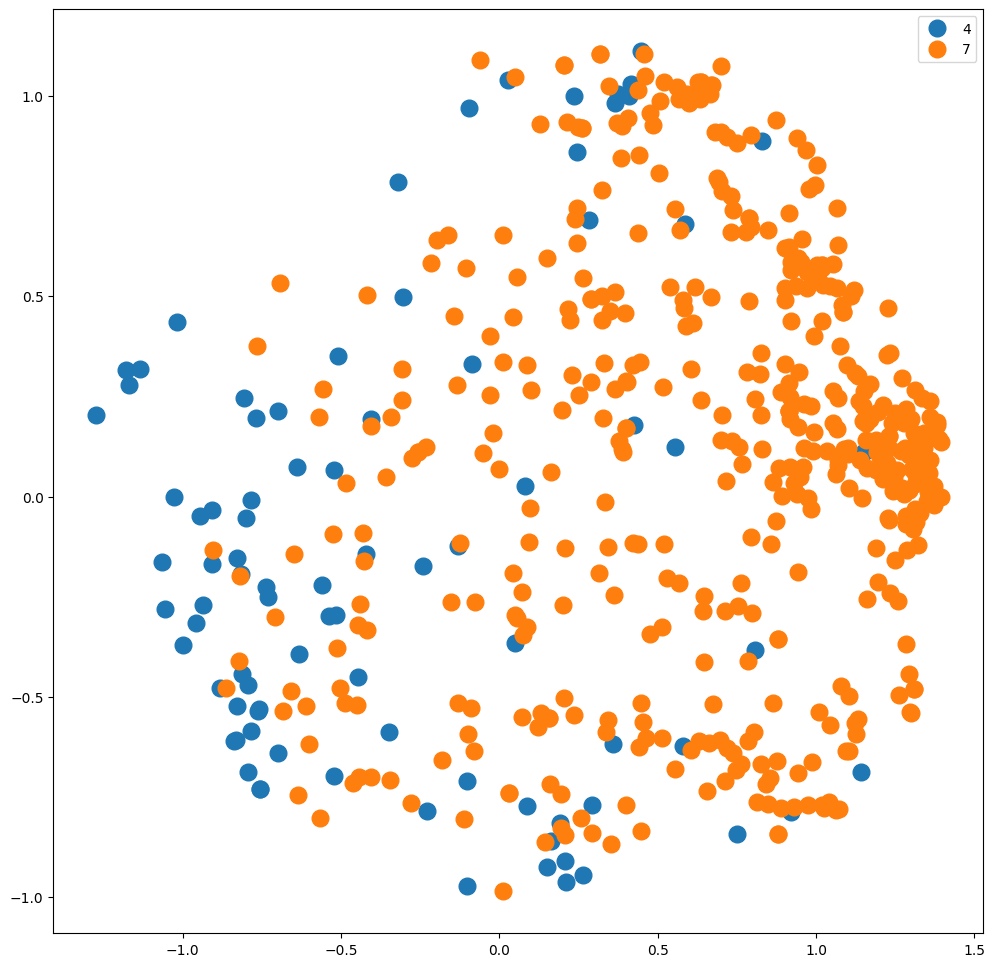

In [16]:
# --- [CELL 15]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 16}
df_tmp = pd.DataFrame(df_tsne, columns=['tsne1', 'tsne2'])
df_TSNE = pd.concat([df_tmp,train[conf.target]], axis=1)

df_TSNE = df_TSNE[(df_TSNE.quality == 4) | (df_TSNE.quality == 7)]

groups = df_TSNE.groupby(conf.target)

#https://stackoverflow.com/questions/21654635/scatter-plots-in-pandas-pyplot-how-to-plot-by-category
fig, ax = plt.subplots(figsize=(12, 12))
ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
for name, group in groups:
    ax.plot(group.tsne1, group.tsne2, marker='o', linestyle='', ms=12, label=name)
ax.legend()
#plt.xlim(-75, -80)
#plt.ylim(-5, 5)

plt.show()

In [17]:
# --- [CELL 16]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 17}
# === BEFORE (original) ===
# df_tmp = train2.drop(columns=['quality'])
# train3 = pd.concat([df_tmp, df_TSNE], axis=1)
# test3 = pd.concat([test2, df_TSNE_te], axis=1)

# === AFTER (edited) ===
df_tmp = train2.drop(columns=['quality']).reset_index(drop=True)

df_TSNE_full = pd.DataFrame(df_tsne, columns=['tsne1', 'tsne2'])
df_TSNE_full = pd.concat([df_TSNE_full, train2['quality'].reset_index(drop=True)], axis=1)

train3 = pd.concat([df_tmp, df_TSNE_full], axis=1)
test3 = pd.concat([test2.reset_index(drop=True), df_TSNE_te.reset_index(drop=True)], axis=1)

In [18]:
# --- [CELL 17]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 18}
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import StratifiedKFold

from lightgbm.sklearn import LGBMClassifier
from catboost import CatBoostClassifier

from lightgbm import LGBMRegressor
import scipy as sp
from functools import partial

import optuna
import warnings
warnings.filterwarnings('ignore')

In [19]:
# --- [CELL 18]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 19}
y = train3[conf.target]
X = train3.drop([conf.target], axis=1)

In [20]:
# --- [CELL 19]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 20}
scores =[]

def find_out_params_model(trial):
    random_state = trial.suggest_int('random_state', 1000, 2000)
    n_splits = trial.suggest_int('n_splits', 8, 20)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=conf.random)
    my_model = LGBMClassifier( 
        random_state = random_state
    )
    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        #print(fold, end=' ')
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train , y_valid = y.iloc[train_idx] , y.iloc[valid_idx]
        my_model.fit(
            X_train, y_train,
            eval_set= [(X_valid,y_valid)],
            early_stopping_rounds = 50,
            verbose=0
        )
        
        preds_valid = my_model.predict(X_valid)
        score = cohen_kappa_score(y_valid,  preds_valid, weights = "quadratic")
        scores.append(score)
    return np.mean(scores)

In [21]:
# --- [CELL 20]: ---
# cell_state: unchanged
# execution_status: {'status': 'error', 'done': True, 'execution_count': 21}
study = optuna.create_study(direction="maximize")
study.optimize(find_out_params_model, n_trials=2)

[I 2026-05-12 07:47:54,869] A new study created in memory with name: no-name-8d878c61-9ef5-4420-a1ce-e2d54e579ab2
[W 2026-05-12 07:47:54,873] Trial 0 failed with parameters: {'random_state': 1941, 'n_splits': 10} because of the following error: TypeError("LGBMClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'").
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "<ipython-input-20-c97154773556>", line 17, in find_out_params_model
    my_model.fit(
TypeError: LGBMClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'
[W 2026-05-12 07:47:54,874] Trial 0 failed with value None.


TypeError: LGBMClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'

In [22]:
assert not y.isna().any(), "y should have no NaN values after filtering"
assert X.index.equals(y.index), "X/y indices are not aligned after filtering"
assert len(X) == len(y), f"X and y lengths should match: {len(X)} vs {len(y)}"